In [1]:
!pip install tensorflow numpy pandas scikit-learn matplotlib

from google.colab import files
uploaded = files.upload()  # upload your CSV files

Saving data_user3.csv to data_user3.csv
Saving data_user4.csv to data_user4.csv
Saving data_user5.csv to data_user5.csv
Saving data_user6.csv to data_user6.csv
Saving data_user7.csv to data_user7.csv


Load users' typing pattens raw dataset.



In [10]:
import pandas as pd
import numpy as np

cols = ['hold0','hold1','hold2','hold3','flight01','flight12','flight23','label']
dfs = []
for uid in [3,4,5,6]:
    df = pd.read_csv(f'data_user{uid}.csv')
    dfs.append(df)
data = pd.concat(dfs, ignore_index=True)

# Remap user IDs to 0 and 4
data['label'] = data['label'].map({3: 0, 4: 1, 5:2, 6:3})

# Drop bad samples: any value <= 5 or > 5000
feature_cols = cols[:7]
mask = (data[feature_cols] > 5).all(axis=1) & (data[feature_cols] < 5000).all(axis=1)
data = data[mask]

print(f"Clean samples: {len(data)}")
print(data['label'].value_counts())
print(data.describe())

Clean samples: 201
label
1    51
0    50
2    50
3    50
Name: count, dtype: int64
             hold0        hold1        hold2        hold3     flight01  \
count   201.000000   201.000000   201.000000   201.000000   201.000000   
mean    334.920398   442.995025   423.522388   300.537313   531.059701   
std     285.280290   313.783946   309.928670   217.953137   415.994827   
min      98.000000    57.000000   108.000000    86.000000   104.000000   
25%     166.000000   159.000000   158.000000   155.000000   206.000000   
50%     213.000000   365.000000   323.000000   201.000000   377.000000   
75%     412.000000   631.000000   623.000000   376.000000   822.000000   
max    1732.000000  1274.000000  1744.000000  1052.000000  1776.000000   

          flight12     flight23       label  
count   201.000000   201.000000  201.000000  
mean    709.940299   717.014925    1.497512  
std     513.104479   518.245844    1.118590  
min     148.000000   103.000000    0.000000  
25%     217.000000  

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = data[feature_cols].values
y = data['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print("Scaler mean:", scaler.mean_.tolist())
print("Scaler std: ", scaler.scale_.tolist())

Train: 160, Test: 41
Scaler mean: [334.92039800995025, 442.9950248756219, 423.5223880597015, 300.53731343283584, 531.0597014925373, 709.9402985074627, 717.0149253731344]
Scaler std:  [284.56975227926, 313.0024159859778, 309.15674226809216, 217.41028881433968, 414.9587240972149, 511.82650824784815, 516.9550677436004]


In [12]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(7,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=8,
                    validation_split=0.2,
                    callbacks=[tf.keras.callbacks.EarlyStopping(
                        patience=15, restore_best_weights=True)])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300 (1.17 KB)

 Trainable params: 300 (1.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.3203 - loss: 1.3022 - val_accuracy: 0.5625 - val_loss: 1.1577
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3438 - loss: 1.2241 - val_accuracy: 0.5938 - val_loss: 1.0753
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4297 - loss: 1.1502 - val_accuracy: 0.7500 - val_loss: 1.0000
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6250 - loss: 1.0797 - val_accuracy: 0.7500 - val_loss: 0.9227
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6562 - loss: 1.0074 - val_accuracy: 0.7812 - val_loss: 0.8469
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6953 - loss: 0.9351 - val_accuracy: 0.7812 - val_loss: 0.7671
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7422 - loss: 0.8566 - val_accuracy: 0.8125 - val_loss: 0.6906
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8359 - loss: 0.7784 - val_accuracy: 0.

100% training and validation accuracy — the model perfectly separates the two users. That's excellent given how distinct user 3 (~150-200ms holds) and user 4 (~800-1000ms holds) are in their typing rhythm.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0046 

Test accuracy: 100.00%
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
              precision    recall  f1-score   support

       user3       1.00      1.00      1.00        10
       user4       1.00      1.00      1.00        11
       user5       1.00      1.00      1.00        10
       user6       1.00      1.00      1.00        10

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



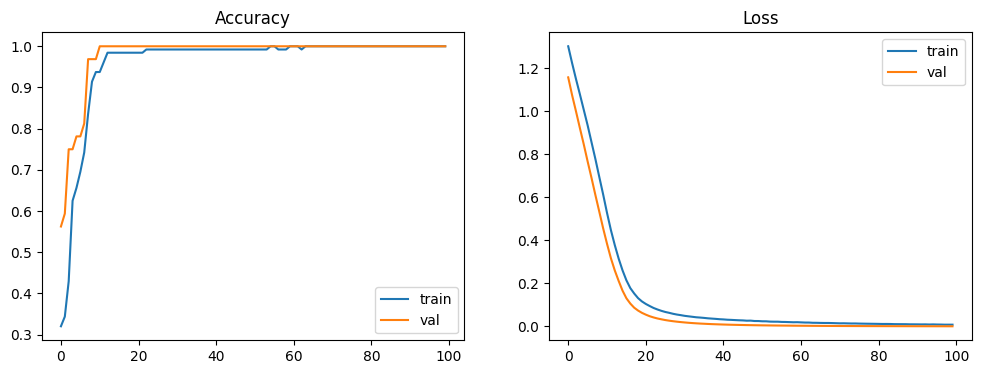

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest accuracy: {acc:.2%}")

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_pred, y_test,
      target_names=['user3', 'user4', 'user5', 'user6']))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.show()

In [14]:
from google.colab import files

def representative_dataset():
    for sample in X_train[:50]:
        yield [sample.reshape(1, 7).astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()
print(f"Model size: {len(tflite_model)} bytes")

c_array = ', '.join(f'0x{b:02x}' for b in tflite_model)
header = f"""#pragma once
#include <stdint.h>
const uint8_t kda_model_data[] = {{{c_array}}};
const int kda_model_data_len = {len(tflite_model)};
"""
with open('kda_model.h', 'w') as f:
    f.write(header)

files.download('kda_model.h')
print("Done!")

Saved artifact at '/tmp/tmpb20plg0o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135812589453136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135812589452752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135812589450256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135812589450448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135812589448528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135810156823184: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model size: 3816 bytes


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


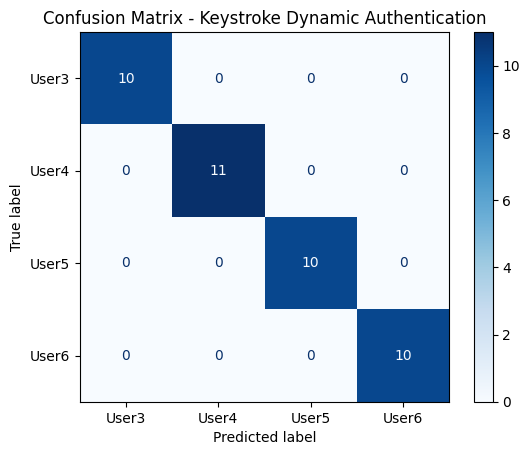

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['User3','User4','User5','User6'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Keystroke Dynamic Authentication')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()